# TP5 - EOQ MEDIFAB

**Source** : Kaggle *Pharma Sales Data* (`salesmonthly.csv`)  
**Produits** : Seringues (N02BE) | Poches (R03) | Implantables (N05C)  
**Periode** : 2016 (n-1 = 2024) | 2018 (n = 2025) | 2019 extrapole (n+1 = 2026)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

MOIS = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']

MAPPING = {
    'Seringues':    {'col': 'N02BE', 'n-1': 45600, 'n': 49100, 'taux_n1': 0.065},
    'Poches':       {'col': 'R03',   'n-1': 18200, 'n': 19800, 'taux_n1': 0.086},
    'Implantables': {'col': 'N05C',  'n-1':  2400, 'n':  2640, 'taux_n1': 0.080},
}

PARAMS_EOQ = {
    'Seringues':    {'S': 150,  'H_annuel': 0.50},
    'Poches':       {'S': 250,  'H_annuel': 2.00},
    'Implantables': {'S': 800,  'H_annuel': 45.0},
}

COULEURS = {'Seringues': '#2196F3', 'Poches': '#4CAF50', 'Implantables': '#FF9800'}

## 1. Chargement du dataset Kaggle

In [2]:
df_raw = pd.read_csv('salesmonthly.csv', parse_dates=['datum'])
df_raw['year']  = df_raw['datum'].dt.year
df_raw['month'] = df_raw['datum'].dt.month

print('Shape :', df_raw.shape)
print('Periode :', df_raw['datum'].min().date(), '->', df_raw['datum'].max().date())
print()
affich = df_raw[['datum','N02BE','R03','N05C']].rename(
    columns={'N02BE':'Seringues','R03':'Poches','N05C':'Implantables'})
print(affich.head(6).to_string(index=False))

Shape : (70, 11)
Periode : 2014-01-31 -> 2019-10-31

     datum  Seringues  Poches  Implantables
2014-01-31    878.030   112.0          50.0
2014-02-28   1001.900   122.0          31.0
2014-03-31    779.275   112.0          20.0
2014-04-30    698.500    97.0          18.0
2014-05-31    628.780   107.0          23.0
2014-06-30    548.225    57.0          23.0


## 2. Extraction des annees de reference (2016 = n-1, 2018 = n)

In [3]:
def extraire_saisonnalite(series):
    total = series.sum()
    return (series / total * 12).values if total > 0 else np.ones(12)

def distribuer_mensuel(total_annuel, saison):
    mensuel = (saison / saison.sum() * total_annuel).astype(int)
    mensuel[-1] += total_annuel - mensuel.sum()
    return mensuel

df_nm1 = df_raw[df_raw['year'] == 2016].sort_values('month').reset_index(drop=True)
df_n   = df_raw[df_raw['year'] == 2018].sort_values('month').reset_index(drop=True)

hist = {'Mois': MOIS}
for produit, cfg in MAPPING.items():
    col = cfg['col']
    hist[produit + '_n-1'] = distribuer_mensuel(cfg['n-1'], extraire_saisonnalite(df_nm1[col]))
    hist[produit + '_n']   = distribuer_mensuel(cfg['n'],   extraire_saisonnalite(df_n[col]))

df_hist = pd.DataFrame(hist)

print(df_hist.to_string(index=False))
print()
for produit in MAPPING:
    t1 = df_hist[produit + '_n-1'].sum()
    t2 = df_hist[produit + '_n'].sum()
    print(f'{produit:<15} n-1={t1:>6,} u  |  n={t2:>6,} u  |  +{((t2-t1)/t1*100):.1f}%')

Mois  Seringues_n-1  Seringues_n  Poches_n-1  Poches_n  Implantables_n-1  Implantables_n
 Jan           5010         4944        1481      1568               278             119
 Fev           4157         5472        2086      1811               231             130
 Mar           3905         4355        2154      1926               150             458
 Avr           3388         3644        1839      1639               208             229
 Mai           3384         2810        1115      1374               208             141
 Jun           2579         2547        1081       723               231             196
 Jul           2214         2961         928       644                92             207
 Aou           2555         3198         987      1138               139             218
 Sep           3796         4613        1030      1467               208             130
 Oct           5488         4922        1873      2527               127             272
 Nov           3606  

## 3. Demande historique mensuelle

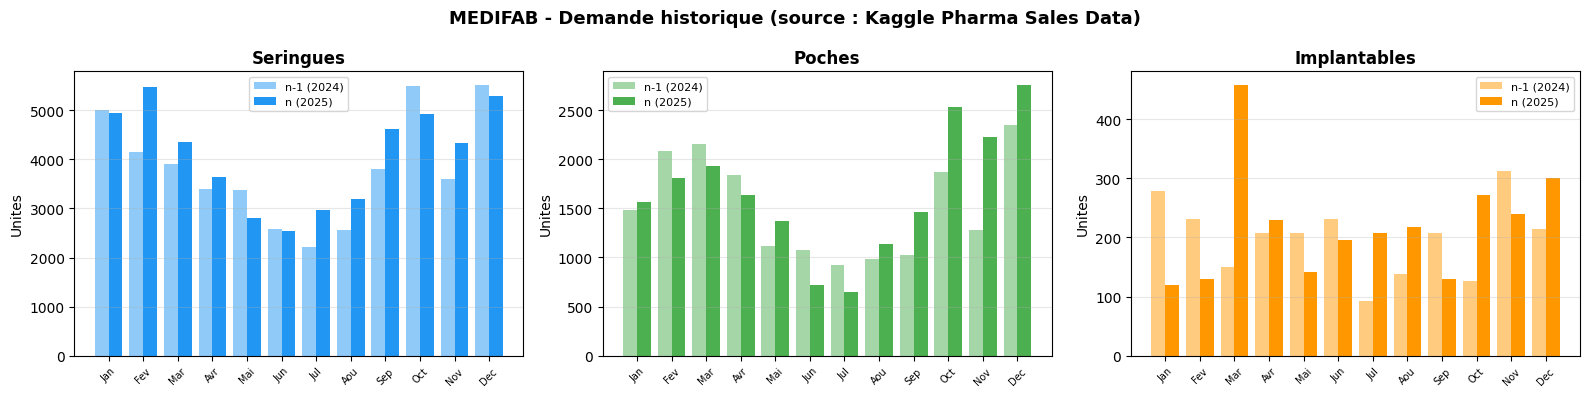

eoq_historique.png sauvegarde


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('MEDIFAB - Demande historique (source : Kaggle Pharma Sales Data)', fontsize=13, fontweight='bold')

for ax, (produit, cfg) in zip(axes, MAPPING.items()):
    x  = np.arange(12)
    y0 = df_hist[produit + '_n-1']
    y1 = df_hist[produit + '_n']
    ax.bar(x - 0.2, y0, 0.4, label='n-1 (2024)', color=COULEURS[produit], alpha=0.5)
    ax.bar(x + 0.2, y1, 0.4, label='n (2025)',   color=COULEURS[produit])
    ax.set_xticks(x)
    ax.set_xticklabels(MOIS, fontsize=7, rotation=45)
    ax.set_title(produit, fontweight='bold')
    ax.set_ylabel('Unites')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eoq_historique.png', dpi=150, bbox_inches='tight')
plt.show()
print('eoq_historique.png sauvegarde')

## 4. Previsions n+1 (2026) — saisonnalite 2019 extrapolee

In [5]:

# 2019 = n+1 dans le dataset Kaggle (10 mois disponibles, nov/dec extrapoles)
df_n1_raw = df_raw[df_raw['year'] == 2019].sort_values('month').reset_index(drop=True)

def extrapoler_annee_incomplete(df_complet, df_partiel, col):
    """Extrapole les mois manquants d un vecteur partiel via le ratio moyen."""
    n_dispo = len(df_partiel)
    ratio = df_partiel[col].sum() / df_complet.iloc[:n_dispo][col].sum()
    serie = df_partiel[col].tolist()
    for m in range(n_dispo, 12):
        serie.append(df_complet.iloc[m][col] * ratio)
    return pd.Series(serie)

prev = {'Mois': MOIS}
for produit, cfg in MAPPING.items():
    col = cfg['col']
    serie_2019 = extrapoler_annee_incomplete(df_n, df_n1_raw, col)
    saison_n1  = extraire_saisonnalite(serie_2019)
    total_n1   = int(cfg['n'] * (1 + cfg['taux_n1']))
    prev[produit + '_n+1'] = distribuer_mensuel(total_n1, saison_n1)

df_prev = pd.DataFrame(prev)

print(df_prev.to_string(index=False))
print()
for produit, cfg in MAPPING.items():
    t = df_prev[produit + '_n+1'].sum()
    print(f'{produit:<15} n+1={t:>6,} u  (+{cfg["taux_n1"]*100:.1f}% vs n)')

Mois  Seringues_n+1  Poches_n+1  Implantables_n+1
 Jan           8712        3031               266
 Fev           5253        1774               139
 Mar           4937        2018               220
 Avr           3398        2033               255
 Mai           3691        2528               301
 Jun           3200        1115               290
 Jul           3409         903               232
 Aou           2718        1138               301
 Sep           5165        1264               185
 Oct           1548         290                81
 Nov           4619        2418               259
 Dec           5641        2990               322

Seringues       n+1=52,291 u  (+6.5% vs n)
Poches          n+1=21,502 u  (+8.6% vs n)
Implantables    n+1= 2,851 u  (+8.0% vs n)


## 5. Calcul EOQ mensuel - Formule de Wilson

In [6]:
resultats_eoq = {}
print(f'{"Produit":<15}  {"S (EUR)":>8}  {"H/an":>6}  {"EOQ min":>8}  {"EOQ max":>8}  {"EOQ moy":>8}')
print('-' * 65)
for produit, params in PARAMS_EOQ.items():
    D         = df_prev[produit + '_n+1'].values
    S         = params['S']
    H_mensuel = params['H_annuel'] / 12
    EOQ       = np.sqrt(2 * D * S / H_mensuel).astype(int)
    resultats_eoq[produit] = EOQ
    print(f'{produit:<15}  {S:>8}  {params["H_annuel"]:>6.2f}  {EOQ.min():>8}  {EOQ.max():>8}  {EOQ.mean():>8.0f}')

Produit           S (EUR)    H/an   EOQ min   EOQ max   EOQ moy
-----------------------------------------------------------------
Seringues             150    0.50      3338      7920      5490
Poches                250    2.00       932      3015      2241
Implantables          800   45.00       185       370       314


## 6. Visualisation - EOQ mensuel n+1

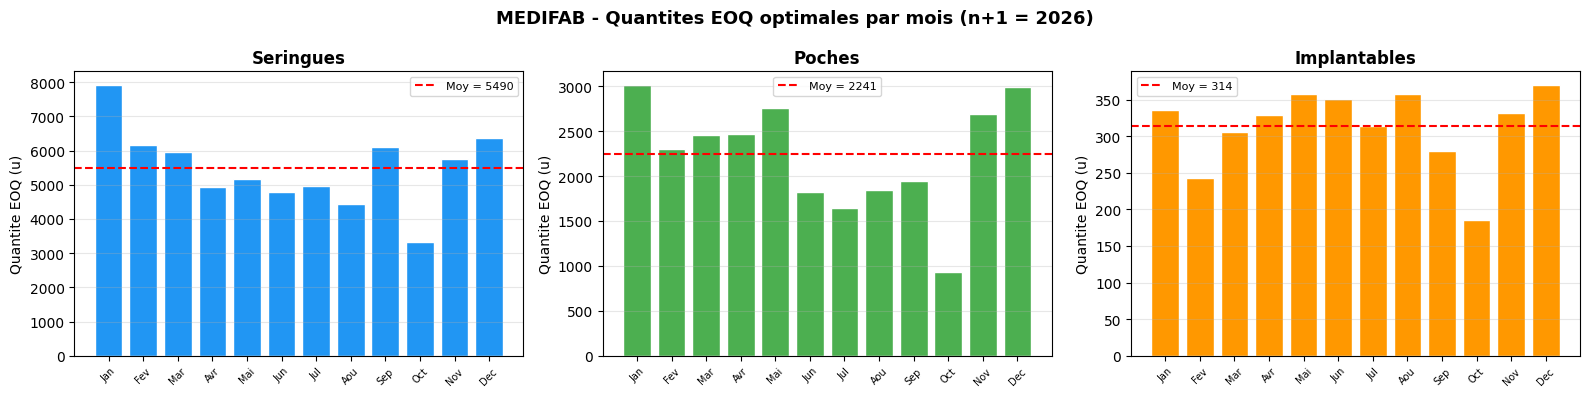

eoq_mensuel.png sauvegarde


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('MEDIFAB - Quantites EOQ optimales par mois (n+1 = 2026)', fontsize=13, fontweight='bold')

for ax, (produit, eoq) in zip(axes, resultats_eoq.items()):
    ax.bar(MOIS, eoq, color=COULEURS[produit], edgecolor='white')
    ax.axhline(eoq.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Moy = {eoq.mean():.0f}')
    ax.set_title(produit, fontweight='bold')
    ax.set_ylabel('Quantite EOQ (u)')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eoq_mensuel.png', dpi=150, bbox_inches='tight')
plt.show()
print('eoq_mensuel.png sauvegarde')

## 7. Comparaison 4 methodes de prevision (Seringues)

In [8]:
D_m1 = df_prev['Seringues_n+1'].values

last6 = df_hist['Seringues_n'].values[-6:]
slope = np.polyfit(range(6), last6, 1)[0]
D_m2 = np.array([last6[-1] + slope * (i+1) for i in range(12)]).clip(min=0).astype(int)

D_m3 = np.full(12, int(MAPPING['Seringues']['n'] / 12))

D_m4 = (D_m1 * 1.15).astype(int)

methodes = {
    'M1 Tendance (ref)':    D_m1,
    'M2 Lineaire 6 mois':   D_m2,
    'M3 Moyenne fixe':      D_m3,
    'M4 Fournisseur x1.15': D_m4,
}

S, H_mensuel = 150, 0.50/12
print(f'{"Methode":<26}  {"D moy":>7}  {"EOQ moy":>8}  {"Cout cmd/an":>13}')
print('-' * 62)
for nom, D in methodes.items():
    EOQ  = np.sqrt(2 * D * S / H_mensuel).astype(int)
    cout = (D / EOQ * S).sum()
    print(f'{nom:<26}  {D.mean():>7.0f}  {EOQ.mean():>8.0f}  {cout:>13,.0f} EUR')

Methode                       D moy   EOQ moy    Cout cmd/an
--------------------------------------------------------------
M1 Tendance (ref)              4358      5490          1,373 EUR
M2 Lineaire 6 mois             8156      7629          1,907 EUR
M3 Moyenne fixe                4091      5427          1,357 EUR
M4 Fournisseur x1.15           5011      5887          1,472 EUR


## 8. Visualisation - Comparaison des 4 methodes

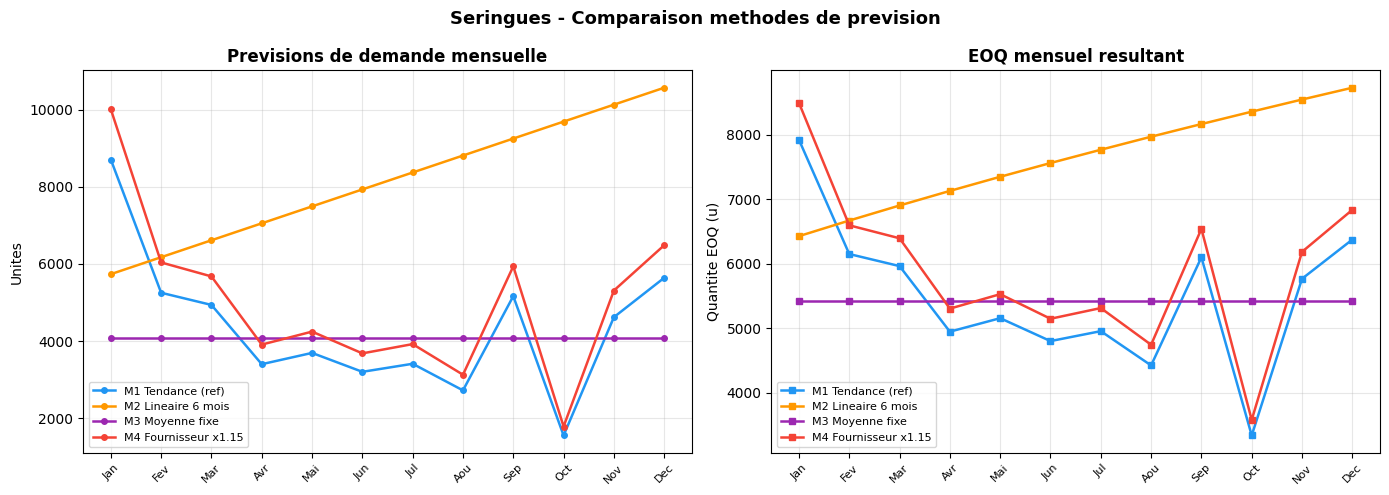

eoq_comparaison.png sauvegarde


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seringues - Comparaison methodes de prevision', fontsize=13, fontweight='bold')

colors_m = ['#2196F3','#FF9800','#9C27B0','#F44336']
for (nom, D), c in zip(methodes.items(), colors_m):
    ax1.plot(MOIS, D, marker='o', label=nom, color=c, linewidth=1.8, markersize=4)
ax1.set_title('Previsions de demande mensuelle', fontweight='bold')
ax1.set_ylabel('Unites')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45, labelsize=8)

for (nom, D), c in zip(methodes.items(), colors_m):
    EOQ = np.sqrt(2 * D * S / H_mensuel).astype(int)
    ax2.plot(MOIS, EOQ, marker='s', label=nom, color=c, linewidth=1.8, markersize=4)
ax2.set_title('EOQ mensuel resultant', fontweight='bold')
ax2.set_ylabel('Quantite EOQ (u)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
ax2.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig('eoq_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()
print('eoq_comparaison.png sauvegarde')

## 9. Export des resultats

In [10]:
rows = []
for produit, params in PARAMS_EOQ.items():
    D         = df_prev[produit + '_n+1'].values
    H_mensuel = params['H_annuel'] / 12
    EOQ       = np.sqrt(2 * D * params['S'] / H_mensuel).astype(int)
    for i, m in enumerate(MOIS):
        rows.append({'Produit': produit, 'Mois': m, 'Demande': int(D[i]),
                     'EOQ': int(EOQ[i]), 'S_EUR': params['S'], 'H_annuel_EUR': params['H_annuel']})

df_export = pd.DataFrame(rows)
df_export.to_csv('eoq_resultats_n1.csv', index=False)

print('=== Synthese EOQ n+1 (2026) ===')
synth = df_export.groupby('Produit').agg(
    Demande_annuelle=('Demande','sum'),
    EOQ_min=('EOQ','min'), EOQ_max=('EOQ','max'), EOQ_moy=('EOQ','mean')
).round(0)
print(synth.to_string())
print()
print('Fichier exporte : eoq_resultats_n1.csv')

=== Synthese EOQ n+1 (2026) ===
              Demande_annuelle  EOQ_min  EOQ_max  EOQ_moy
Produit                                                  
Implantables              2851      185      370    314.0
Poches                   21502      932     3015   2241.0
Seringues                52291     3338     7920   5490.0

Fichier exporte : eoq_resultats_n1.csv
